![header](https://drive.google.com/uc?export=view&id=1KuEspEp7OwqGw6uMRJvYE6BVE-Zo-8JF)

 <h1> <div align="center"> Dr. David Antonio-Torres</div> </h1>

# Redes Neuronales Profundas para Clasificación Multiclase
### Se hace uso del dataset MNIST para reconocimiento de dígitos
### https://keras.io/api/datasets/

## Entorno de ejecución y referencias

🔗 **Repositorio GitHub:** [https://github.com/joelbecv/MNA_WORKSPACE](https://github.com/joelbecv/MNA_WORKSPACE)  
📁 **Archivo:** `4.3 deep_learning_keras_b.ipynb`

### ¿Dónde puedo correr este notebook?

| Entorno | Estado | Tiempo estimado | Notas |
|---------|--------|-----------------|-------|
| 💻 Mac M5 (local) | ✅ Funciona | ~2-3 minutos | GPU Metal activo |
| ☁️ Google Colab | ✅ Funciona | ~1-2 minutos | GPU gratuita disponible |

### 🔧 Cambios ya aplicados en este notebook para TF 2.18

```python
# ANTES (Colab/Keras 2)                          →  DESPUÉS (TF 2.18 local)
from keras.datasets import mnist                   →  from tensorflow.keras.datasets import mnist
from keras.utils.np_utils import to_categorical    →  from tensorflow.keras.utils import to_categorical
from keras.layers import Dense, Dropout            →  from tensorflow.keras.layers import Dense, Dropout
Adam(lr=0.01)                                      →  Adam(learning_rate=0.01)
```

⚠️ El cambio de `keras.utils.np_utils` es **crítico** — esa ruta ya no existe en Keras 3 y daría error sin este fix.

## ¿Qué hace este notebook?

Entrena una red neuronal densa (MLP) para **reconocer dígitos escritos a mano** del dataset MNIST.

### El dataset MNIST — el "Hola Mundo" del deep learning

- **70,000 imágenes** de dígitos del 0 al 9, escritos a mano por personas reales
- Cada imagen es de **28 × 28 píxeles** en escala de grises
- **60,000 para entrenamiento**, 10,000 para prueba
- El objetivo: dado una imagen, predecir qué dígito es (0-9)

### 🔧 Paso clave: aplanar la imagen

Cada imagen es una matriz 28×28. Una red densa (Dense) no puede recibir matrices — necesita un vector plano:

```python
# ANTES de entrar al modelo: 
# imagen shape = (28, 28)  →  vector shape = (784,)
X_train = X_train.reshape(60000, 784)  # 28 × 28 = 784 píxeles en fila
```

**¿Qué significa `reshape`?** Toma la imagen de 28 filas × 28 columnas y la "estira" en una sola fila de 784 números. Como enrollar una fotografía en un tubo.

### Lo nuevo respecto a 4.3a: Dropout

```python
# model.add(Dropout(0.2))  ← aparece comentado en el código original
```

`Dropout(0.2)` significa: durante el entrenamiento, apagar aleatoriamente el 20% de las neuronas en cada paso. Esto **previene el overfitting** — el modelo no puede memorizar los datos de entrenamiento porque cada vez trabaja con neuronas diferentes. Se activa/desactiva con un comentario (#).

# Se cargan las bibliotecas necesarias

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
import random

# para el generador de aleatorios
np.random.seed(0)

# Se carga el dataset y se verifica el número de muestras en cada set
### Nótese que al hacer la carga, se genera automáticamente el set de entrenamiento y el set de pruebas
### Las imágenes son en escala de grises y de 28 por 28 pixeles

In [19]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
     
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)


# Se verifica el número de muestras por dígito

Text(0, 0.5, 'Número de Muestras')

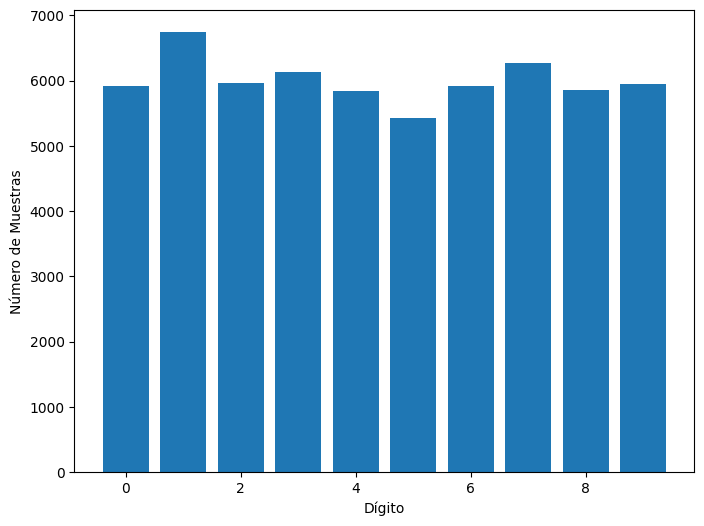

In [20]:
n_muestras = []
n_digitos = 10

for n in range(n_digitos):
    x_sel = X_train[y_train == n]
    n_muestras.append(len(x_sel))
plt.figure(figsize=(8,6))
plt.bar(range(0,n_digitos), n_muestras)
plt.xlabel("Dígito")
plt.ylabel("Número de Muestras")

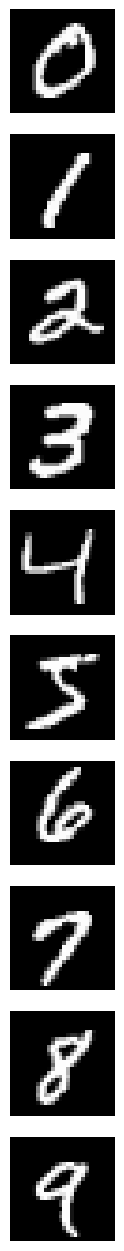

In [21]:
n_digitos = 10

fig, axs = plt.subplots(n_digitos, figsize=(16,16))
for n in range(n_digitos):
    x_sel = X_train[y_train == n]
    axs[n].imshow(x_sel[0],cmap='gray')
    axs[n].axis('off')


# One-hot Encoding para las etiquetas de ambos sets

In [22]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Se normalizan las intensidades de los pixeles en un intervalo de 0 y 1

In [23]:
X_train = X_train/255 
X_test = X_test/255

# Se unidimensionan las imágenes para adecuarlas como capa de entrada en la red neuronal

In [24]:
# 28 x 28 = 784
num_pixels = 784
X_train = X_train.reshape(X_train.shape[0], num_pixels)
X_test = X_test.reshape(X_test.shape[0], num_pixels)
print(X_train.shape)
print(X_test.shape)

(60000, 784)
(10000, 784)


# Se define el modelo

In [25]:
model = Sequential()
model.add(Dense(units = 30, input_dim=num_pixels, activation='relu'))
#model.add(Dropout(0.2))
model.add(Dense(units = 10, activation='relu'))
#model.add(Dropout(0.2))
model.add(Dense(units = 10, activation='softmax'))
model.compile(Adam(learning_rate=0.01), loss='categorical_crossentropy', metrics=['accuracy'])
print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 30)             │        23,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,970 (93.63 KB)

 Trainable params: 23,970 (93.63 KB)

 Non-trainable params: 0 (0.00 B)

None


# Se separa un 10% del set de entrenamiento para fines de validación

In [26]:
history = model.fit(X_train, y_train, validation_split=0.1, epochs = 10, batch_size = 200, verbose = 1, shuffle = 1)

Epoch 1/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6997 - loss: 0.9927 - val_accuracy: 0.8515 - val_loss: 0.5856
Epoch 2/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7567 - loss: 1.8901 - val_accuracy: 0.7835 - val_loss: 2.6675
Epoch 3/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7251 - loss: 5.0213 - val_accuracy: 0.7927 - val_loss: 4.0781
Epoch 4/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6924 - loss: 11.8775 - val_accuracy: 0.6900 - val_loss: 15.9836
Epoch 5/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7133 - loss: 15.9413 - val_accuracy: 0.7437 - val_loss: 15.1380
Epoch 6/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7227 - loss: 19.5847 - val_accuracy: 0.7448 - val_loss: 21.6594
Epoch 7/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7141 - loss: 29.0849 - val_accuracy: 0.8017 - val_loss: 14.5552
Epoch 8/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7270 - loss: 32.3390 - val_acc

In [27]:
scores = model.evaluate(X_test, y_test, verbose=1)
print('Test loss:', scores[0])
print('Test accuracy:', scores[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7770 - loss: 41.9195
Test loss: 41.91946029663086
Test accuracy: 0.7770000100135803


Text(0.5, 0, 'epoch')

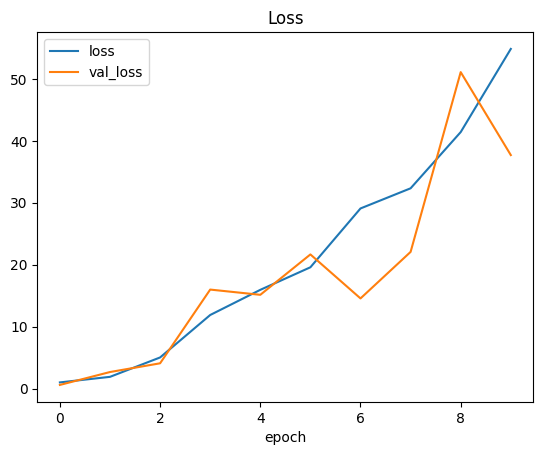

In [28]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.title('Loss')
plt.xlabel('epoch')

Text(0.5, 0, 'epoch')

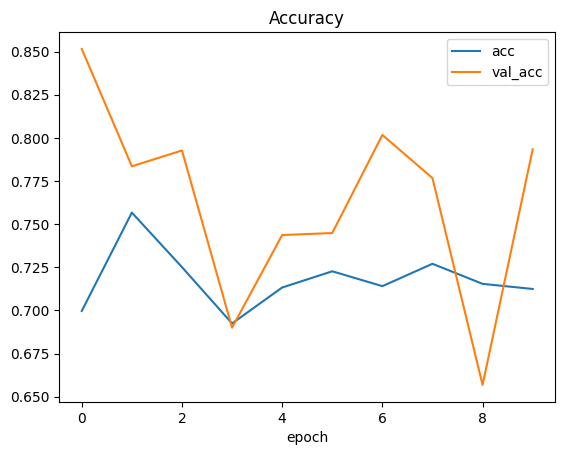

In [29]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['acc', 'val_acc'])
plt.title('Accuracy')
plt.xlabel('epoch')

# Verificamos la clasificación con el set de prueba

In [30]:
score = model.evaluate(X_test, y_test, verbose=0)
print(type(score))
print('Test score:', score[0])
print('Test accuracy:', score[1])

<class 'list'>
Test score: 41.91946029663086
Test accuracy: 0.7770000100135803


# Se somete a prueba con una imagen de la web

## Predicción con una imagen nueva

Esta sección descarga una imagen real de un dígito desde internet y la pasa por el modelo para hacer una predicción.

### 🔧 CAMBIO vs Colab:
En Colab esta celda necesita instalar `requests` y `PIL`. En tu Mac M5 ya están disponibles en el entorno `ml_env`.

**¿Qué hace este bloque?**
1. Descarga una imagen PNG de un "4" escrito a mano desde un blog de ML
2. La redimensiona a 28×28 píxeles (el tamaño que espera el modelo)
3. La convierte a escala de grises e invierte los colores (MNIST tiene fondo negro, la imagen tiene fondo blanco)
4. La normaliza y aplana para pasarla al modelo
5. El modelo predice qué dígito es

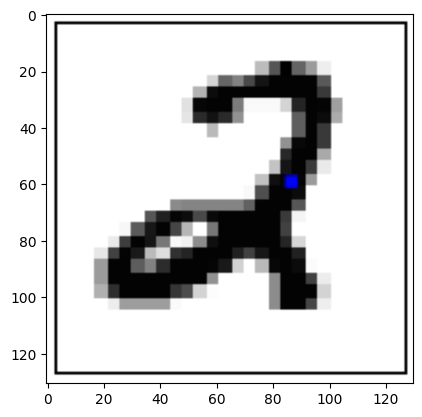

In [31]:
import requests
from PIL import Image
     
url = 'https://colah.github.io/posts/2014-10-Visualizing-MNIST/img/mnist_pca/MNIST-p1815-4.png'
response = requests.get(url, stream=True)
img = Image.open(response.raw)
plt.imshow(img, cmap=plt.get_cmap('gray'))

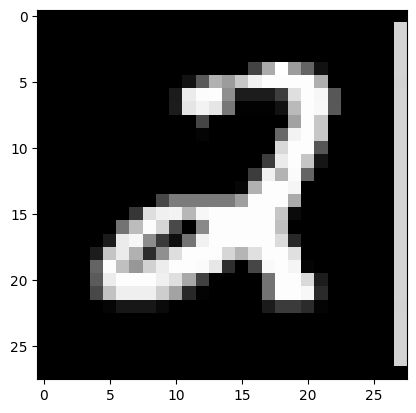

In [32]:
import cv2
     
img_arr = np.asarray(img)
img_rs = cv2.resize(img_arr, (28, 28))
img_gray = cv2.cvtColor(img_rs, cv2.COLOR_BGR2GRAY)
img_not = cv2.bitwise_not(img_gray)
plt.imshow(img_not, cmap=plt.get_cmap('gray'))
     


In [33]:
img_not = img_not/255
img_resh = img_not.reshape(1, 784)

prediction = np.argmax(model.predict(img_resh), axis=-1)
print("predicted digit:", str(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
predicted digit: [2]


# Guardando y descargando el modelo

In [34]:
# Guardar el modelo entrenado
model.save('model.h5')
print("Modelo guardado como 'model.h5' en la carpeta del notebook")

# 🔧 CAMBIO respecto al original de Colab:
# El original tenía:
#   from google.colab import files
#   files.download('model.h5')
# google.colab solo existe en Google Colab, no en Mac local.
# En Mac el archivo queda guardado automáticamente en la misma carpeta.
# Para cargarlo más tarde: model = tf.keras.models.load_model('model.h5')

Modelo guardado como 'model.h5' en la carpeta del notebook


# Gracias por la atención